# Project #5 – North Dakota Pipeline Water Quality Analysis

In [1]:
# Import packages used for data cleaning, calculations, and graphs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load original water quality dataset
df = pd.read_csv('Project5.csv')

# Check dataset size and preview
print('Shape:', df.shape)
df.head()

Shape: (25697, 57)


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityRelativeDepthName,...,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LastUpdated,ProviderName,activity_date,year,month,location_order,location_name
0,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-7863P,Field Msr/Obs,Water,NaN,8/16/2013,7:35:00,CST,NaN,...,NaN,NaN,NaN,2015-09-17T10:39:36Z,STORET,8/16/2013,2013,8,21NDHDWQ_WQX-382003,Lake Sakakawea
1,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-13-R1573,Sample-Routine,Water,NaN,7/8/2013,9:18:00,CST,NaN,...,NaN,NaN,NaN,2014-03-17T13:39:19Z,STORET,7/8/2013,2013,7,21NDHDWQ_WQX-381171,Lake Ashtabula
2,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-13-R2319,Sample-Routine,Water,NaN,8/19/2013,11:30:00,CST,NaN,...,NaN,NaN,NaN,2014-03-17T13:50:58Z,STORET,8/19/2013,2013,8,21NDHDWQ_WQX-381171,Lake Ashtabula
3,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-8371P,Field Msr/Obs,Water,NaN,6/27/2013,NaN,NaN,NaN,...,NaN,NaN,NaN,2017-10-06T15:07:18Z,STORET,6/27/2013,2013,6,21NDHDWQ_WQX-381171,Lake Ashtabula
4,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-8379P,Field Msr/Obs,Water,NaN,7/22/2013,NaN,NaN,NaN,...,NaN,NaN,NaN,2017-10-06T15:07:19Z,STORET,7/22/2013,2013,7,21NDHDWQ_WQX-381171,Lake Ashtabula


In [3]:
# View column names
df.columns.tolist()

['OrganizationIdentifier',
 'OrganizationFormalName',
 'ActivityIdentifier',
 'ActivityTypeCode',
 'ActivityMediaName',
 'ActivityMediaSubdivisionName',
 'ActivityStartDate',
 'ActivityStartTime/Time',
 'ActivityStartTime/TimeZoneCode',
 'ActivityRelativeDepthName',
 'ActivityDepthHeightMeasure/MeasureValue',
 'ActivityDepthHeightMeasure/MeasureUnitCode',
 'ActivityTopDepthHeightMeasure/MeasureValue',
 'ActivityTopDepthHeightMeasure/MeasureUnitCode',
 'ActivityBottomDepthHeightMeasure/MeasureValue',
 'ActivityBottomDepthHeightMeasure/MeasureUnitCode',
 'ProjectIdentifier',
 'ProjectName',
 'ActivityConductingOrganizationText',
 'MonitoringLocationIdentifier',
 'MonitoringLocationName',
 'ActivityCommentText',
 'ActivityLocation/LatitudeMeasure',
 'ActivityLocation/LongitudeMeasure',
 'SampleCollectionMethod/MethodIdentifier',
 'SampleCollectionMethod/MethodIdentifierContext',
 'SampleCollectionMethod/MethodName',
 'SampleCollectionEquipmentName',
 'ResultIdentifier',
 'ResultDetectionC

## 3. Clean Data

In [4]:
# Convert measured values to numbers
df['ResultMeasureValue'] = pd.to_numeric(df['ResultMeasureValue'], errors='coerce')

# Replace invalid values with missing values
df_clean = df.replace(-9999, np.nan)

# Drop rows missing important analysis information
df_clean = df_clean.dropna(subset=['ResultMeasureValue', 'CharacteristicName', 'location_name'])

# Check cleaning result
print('Rows before cleaning:', len(df))
print('Rows after cleaning:', len(df_clean))
print('Rows removed:', len(df) - len(df_clean))

df_clean.head()

Rows before cleaning: 25697
Rows after cleaning: 24026
Rows removed: 1671


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityRelativeDepthName,...,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LastUpdated,ProviderName,activity_date,year,month,location_order,location_name
0,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-7863P,Field Msr/Obs,Water,NaN,8/16/2013,7:35:00,CST,NaN,...,NaN,NaN,NaN,2015-09-17T10:39:36Z,STORET,8/16/2013,2013,8,21NDHDWQ_WQX-382003,Lake Sakakawea
1,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-13-R1573,Sample-Routine,Water,NaN,7/8/2013,9:18:00,CST,NaN,...,NaN,NaN,NaN,2014-03-17T13:39:19Z,STORET,7/8/2013,2013,7,21NDHDWQ_WQX-381171,Lake Ashtabula
2,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-13-R2319,Sample-Routine,Water,NaN,8/19/2013,11:30:00,CST,NaN,...,NaN,NaN,NaN,2014-03-17T13:50:58Z,STORET,8/19/2013,2013,8,21NDHDWQ_WQX-381171,Lake Ashtabula
3,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-8371P,Field Msr/Obs,Water,NaN,6/27/2013,NaN,NaN,NaN,...,NaN,NaN,NaN,2017-10-06T15:07:18Z,STORET,6/27/2013,2013,6,21NDHDWQ_WQX-381171,Lake Ashtabula
4,21NDHDWQ_WQX,North Dakota Department Of Environmental Quality,21NDHDWQ_WQX-2013-8379P,Field Msr/Obs,Water,NaN,7/22/2013,NaN,NaN,NaN,...,NaN,NaN,NaN,2017-10-06T15:07:19Z,STORET,7/22/2013,2013,7,21NDHDWQ_WQX-381171,Lake Ashtabula


In [5]:
# Check missing values in important columns
key_cols = ['CharacteristicName', 'ResultMeasureValue', 'location_name', 'ResultMeasure/MeasureUnitCode']

df_clean[key_cols].isnull().sum()

CharacteristicName                  0
ResultMeasureValue                  0
location_name                       0
ResultMeasure/MeasureUnitCode    6227
dtype: int64

## 4. Filter Parameters

In [6]:
# Water quality parameters of interest
parameters_of_interest = [
    'Total dissolved solids',
    'Sulfate',
    'pH',
    'Magnesium',
    'Bicarbonate',
    'Calcium',
    'Hardness, carbonate',
    'Chloride',
    'Sodium',
    'Carbonate',
    'Sodium adsorption ratio [(Na)/(sq root of 1/2 Ca + Mg)]'
]

# Filter dataset to selected parameters
param_df = df_clean[df_clean['CharacteristicName'].isin(parameters_of_interest)].copy()

print('Records with parameters of interest:', len(param_df))
param_df['CharacteristicName'].value_counts()

Records with parameters of interest: 12859


CharacteristicName
pH                                                         5545
Sodium                                                     1364
Sulfate                                                     700
Chloride                                                    693
Total dissolved solids                                      683
Magnesium                                                   682
Calcium                                                     682
Sodium adsorption ratio [(Na)/(sq root of 1/2 Ca + Mg)]     682
Hardness, carbonate                                         682
Bicarbonate                                                 681
Carbonate                                                   465
Name: count, dtype: int64

## 5. Filter Locations

In [7]:
# Main locations used in the analysis
locations_of_interest = ['Lake Sakakawea', 'Sheyenne River - Lisbon', 'Lake Ashtabula']

# Order locations from source to destination
location_order = ['Lake Sakakawea', 'Sheyenne River - Lisbon', 'Lake Ashtabula']

# Filter to locations of interest
filtered_df = param_df[param_df['location_name'].isin(locations_of_interest)].copy()

# Set correct location order for graphs
filtered_df['location_name'] = pd.Categorical(
    filtered_df['location_name'],
    categories=location_order,
    ordered=True
)

print('Records in analysis locations:', len(filtered_df))
filtered_df.groupby('location_name', observed=False)['CharacteristicName'].count()

Records in analysis locations: 9952


location_name
Lake Sakakawea             4321
Sheyenne River - Lisbon    1089
Lake Ashtabula             4542
Name: CharacteristicName, dtype: int64

## 6. Summary Statistics

In [8]:
# Calculate summary statistics by location and parameter
summary_stats = filtered_df.groupby(
    ['location_name', 'CharacteristicName'],
    observed=False
)['ResultMeasureValue'].agg(
    Mean='mean',
    Median='median',
    Min='min',
    Max='max',
    Count='count'
).round(2).reset_index()

summary_stats

,location_name,CharacteristicName,Mean,Median,Min,Max,Count
0,Lake Sakakawea,Bicarbonate,186.37,186.00,157.00,214.00,78
1,Lake Sakakawea,Calcium,49.45,49.50,41.00,56.10,78
2,Lake Sakakawea,Carbonate,5.23,5.00,1.00,15.00,56
3,Lake Sakakawea,Chloride,10.02,10.10,8.44,11.20,78
4,Lake Sakakawea,"Hardness, carbonate",205.49,205.00,183.00,243.00,78
5,Lake Sakakawea,Magnesium,19.89,19.70,17.50,25.60,78
6,Lake Sakakawea,Sodium,45.84,44.35,32.10,74.10,156
7,Lake Sakakawea,Sodium adsorption ratio [(Na)/(sq root of 1/2 ...,1.68,1.64,1.38,2.16,78
8,Lake Sakakawea,Sulfate,158.64,159.00,133.00,224.00,78
9,Lake Sakakawea,Total dissolved solids,394.60,394.50,341.00,476.00,78


In [9]:
# Save summary statistics table
summary_stats.to_csv('project5_summary_statistics.csv', index=False)

print('Summary statistics saved.')

Summary statistics saved.


## 7. Graph 1 – Boxplots of Key Parameters by Location

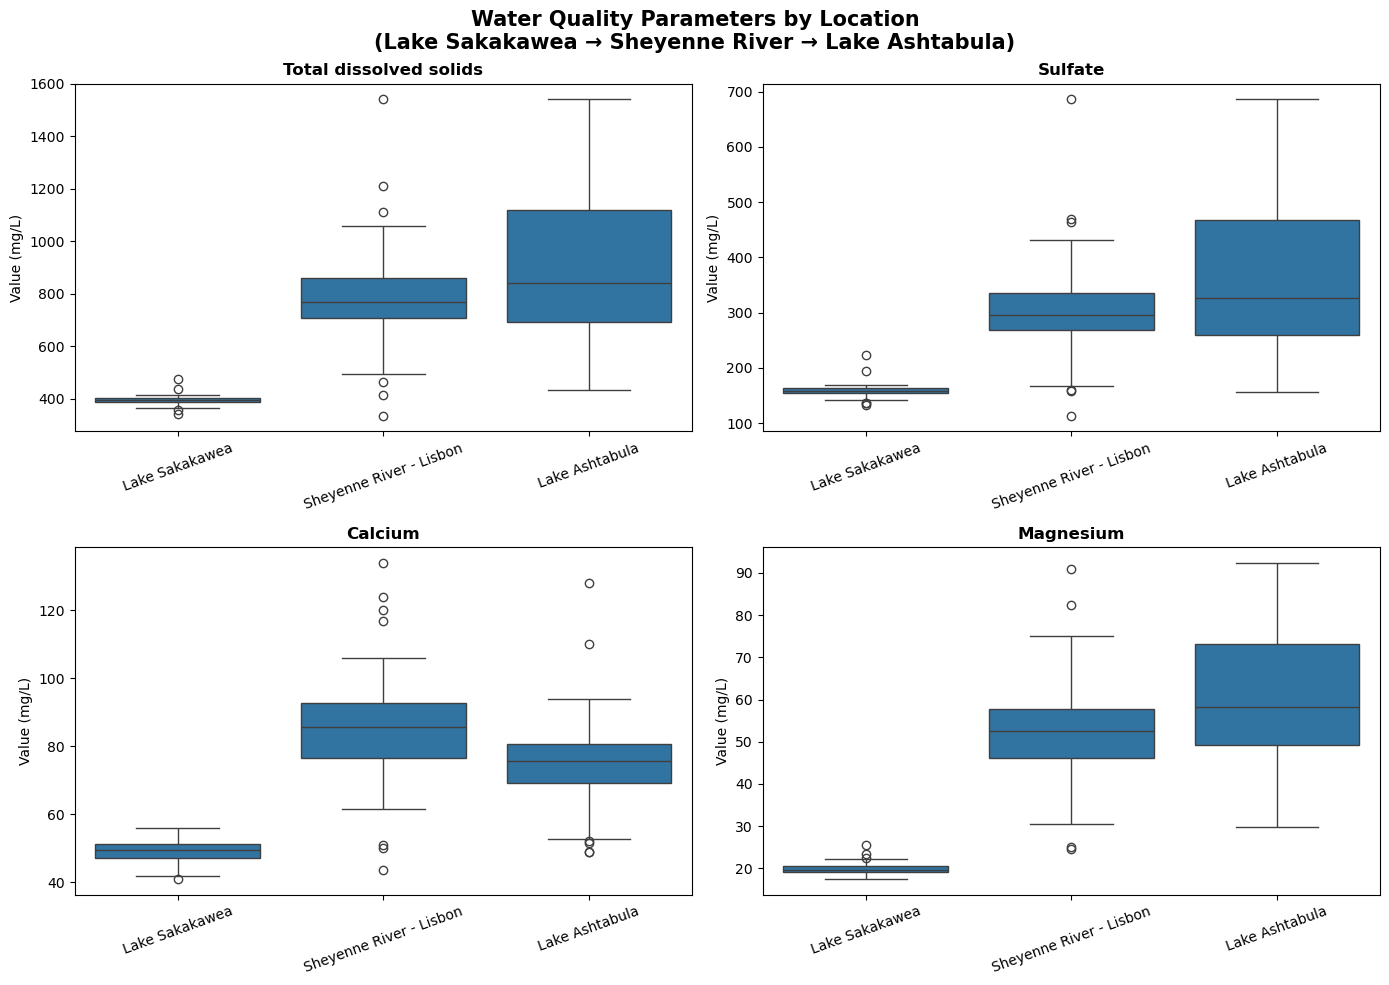

In [10]:
# Select four water quality parameters for boxplots
boxplot_params = ['Total dissolved solids', 'Sulfate', 'Calcium', 'Magnesium']

# Filter to selected boxplot parameters
box_df = filtered_df[filtered_df['CharacteristicName'].isin(boxplot_params)]

# Create 2 by 2 boxplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle('Water Quality Parameters by Location\n(Lake Sakakawea → Sheyenne River → Lake Ashtabula)',
             fontsize=15, fontweight='bold')

for ax, param in zip(axes.flatten(), boxplot_params):
    subset = box_df[box_df['CharacteristicName'] == param]

    unit_series = subset['ResultMeasure/MeasureUnitCode']
    unit = unit_series.mode()[0] if not unit_series.empty else ''

    sns.boxplot(data=subset, x='location_name', y='ResultMeasureValue', ax=ax)

    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(f'Value ({unit})')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 8. Graph 2 – Average TDS Trend Along the System

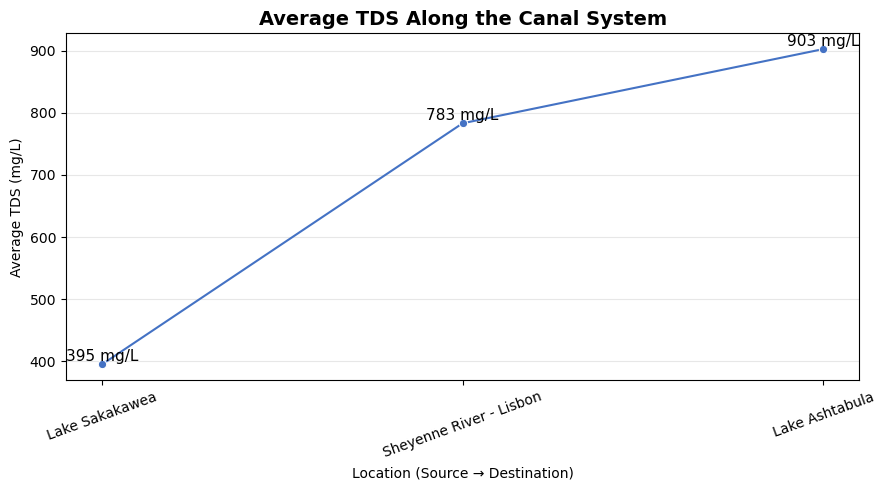

In [11]:
# Filter summary table to Total Dissolved Solids
tds_means = summary_stats[summary_stats['CharacteristicName'] == 'Total dissolved solids'].copy()

# Sort locations in correct order
tds_means = tds_means.sort_values('location_name')

# Create line graph
fig2, ax2 = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=tds_means,
    x='location_name',
    y='Mean',
    marker='o',
    color='#4472C4',
    ax=ax2
)

# Add value labels above points
for i, row in tds_means.iterrows():
    ax2.text(row['location_name'], row['Mean'] + 5,
             f"{row['Mean']:.0f} mg/L",
             ha='center', fontsize=11)

ax2.set_title('Average TDS Along the Canal System', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location (Source → Destination)')
ax2.set_ylabel('Average TDS (mg/L)')
ax2.grid(axis='y', alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 9. Functions

In [12]:
# Function for mass loading
def mass_loading(flow_rate, concentration):
    load = flow_rate * concentration
    return round(load, 2)


# Function for mixed TDS concentration
def tds_mixing(pipe_flow, pipe_tds, river_flow, river_tds):
    mixed_tds = (pipe_flow * pipe_tds + river_flow * river_tds) / (pipe_flow + river_flow)
    return round(mixed_tds, 2)


# Test functions
example_load = mass_loading(6, 600)
example_mixed_tds = tds_mixing(pipe_flow=6, pipe_tds=600, river_flow=20, river_tds=700)

print('Example pipe TDS load:', example_load)
print('Example mixed TDS:', example_mixed_tds, 'mg/L')

Example pipe TDS load: 3600
Example mixed TDS: 676.92 mg/L


## 10. Scenario Testing

In [13]:
# Create scenario table
scenarios = pd.DataFrame({
    'Scenario':    ['Low Flow',  'Base Case', 'High Flow'],
    'pipe_flow':   [6,           6,           6],
    'pipe_tds':    [550,         600,         650],
    'river_flow':  [15,          20,          25],
    'river_tds':   [680,         700,         720]
})

# Calculate mass loading for each source
scenarios['Pipe TDS Load'] = scenarios.apply(
    lambda row: mass_loading(row['pipe_flow'], row['pipe_tds']),
    axis=1
)

scenarios['River TDS Load'] = scenarios.apply(
    lambda row: mass_loading(row['river_flow'], row['river_tds']),
    axis=1
)

# Calculate mixed flow
scenarios['Lake Ashtabula Flow (cfs)'] = scenarios['pipe_flow'] + scenarios['river_flow']

# Calculate mixed TDS for each scenario
scenarios['Mixed TDS (mg/L)'] = scenarios.apply(
    lambda row: tds_mixing(row['pipe_flow'], row['pipe_tds'], row['river_flow'], row['river_tds']),
    axis=1
)

scenarios

,Scenario,pipe_flow,pipe_tds,river_flow,river_tds,Pipe TDS Load,River TDS Load,Lake Ashtabula Flow (cfs),Mixed TDS (mg/L)
0,Low Flow,6,550,15,680,3300,10200,21,642.86
1,Base Case,6,600,20,700,3600,14000,26,676.92
2,High Flow,6,650,25,720,3900,18000,31,706.45


## 11. Graph 3 – Predicted Mixed TDS by Scenario

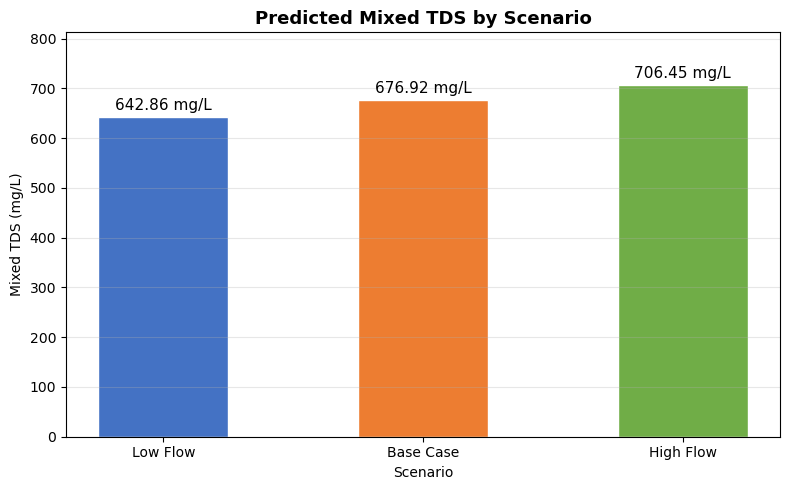

In [14]:
# Create bar chart for scenario results
fig3, ax3 = plt.subplots(figsize=(8, 5))

ax3.bar(scenarios['Scenario'], scenarios['Mixed TDS (mg/L)'],
        color=['#4472C4', '#ED7D31', '#70AD47'],
        edgecolor='white', width=0.5)

# Add labels above bars
for i, row in scenarios.iterrows():
    ax3.text(i, row['Mixed TDS (mg/L)'] * 1.02,
             f"{row['Mixed TDS (mg/L)']} mg/L",
             ha='center', fontsize=11)

ax3.set_title('Predicted Mixed TDS by Scenario', fontsize=13, fontweight='bold')
ax3.set_xlabel('Scenario')
ax3.set_ylabel('Mixed TDS (mg/L)')
ax3.set_ylim(0, max(scenarios['Mixed TDS (mg/L)']) * 1.15)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()